<a href="https://colab.research.google.com/github/lilianabs/text-classification-hf/blob/main/1_Zero_Shot_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install transformers datasets

In [10]:
from datasets import load_dataset
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset

import pandas as pd
import matplotlib.pyplot as plt

In [21]:
pd.set_option('display.max_colwidth', None)

In [12]:
dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset",
    split="train"
)

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

In [13]:
dataset.set_format(type="pandas")

df = dataset[:]
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   flags           26872 non-null  object
 1   instruction     26872 non-null  object
 2   category        26872 non-null  object
 3   intent          26872 non-null  object
 4   response        26872 non-null  object
 5   special_tokens  26872 non-null  object
dtypes: object(6)
memory usage: 1.2+ MB


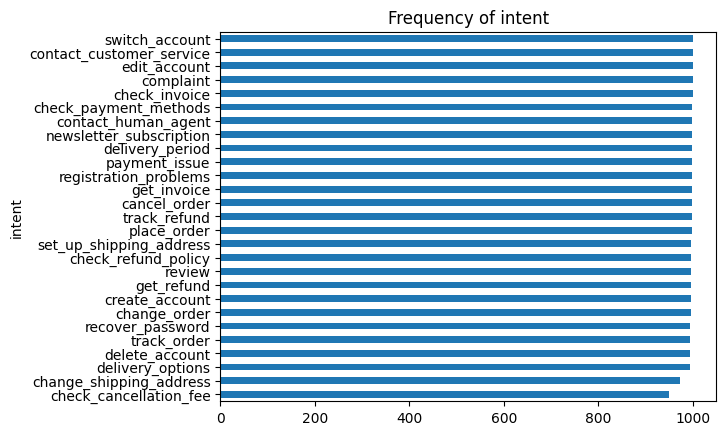

In [15]:
df["intent"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of intent")
plt.show()

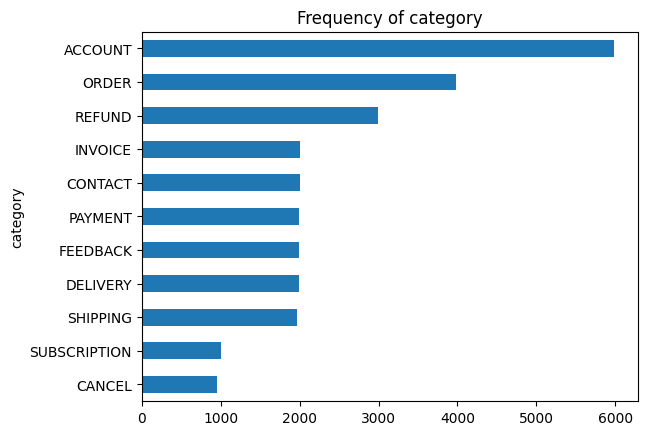

In [16]:
df["category"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of category")
plt.show()

### Extracting Special Tokens

In [17]:
import re

def extract_special_tokens(text):
    """
    Extracts special tokens enclosed in double curly braces {{}} from a given text.
    """
    if isinstance(text, str):
        return re.findall(r'\{\{([^}]+)\}\}', text)
    return []

# Apply the function to the 'instruction' column and store the results in a new column
df['special_tokens'] = df['instruction'].apply(extract_special_tokens)

# Display the first few rows with the new column
display(df[['instruction', 'special_tokens']].head())

,instruction,special_tokens
0,question about cancelling order {{Order Number}},[Order Number]
1,i have a question about cancelling oorder {{Or...,[Order Number]
2,i need help cancelling puchase {{Order Number}},[Order Number]
3,I need to cancel purchase {{Order Number}},[Order Number]
4,"I cannot afford this order, cancel purchase {{...",[Order Number]


In [19]:
df['special_tokens'].value_counts()

,count
special_tokens,
[],20202
[Order Number],2907
[Account Type],1011
[Person Name],887
[Account Category],822
"[Currency Symbol, Refund Amount]",372
[Refund Amount],252
[Delivery City],234
[Delivery Country],177


### Sample 10 rows from each intent

In [27]:
# Group by 'intent' and sample 10 examples from each group
sampled_df = df.groupby('intent').apply(lambda x: x.sample(n=10, random_state=42)).reset_index(drop=True)

# Display the shape and some examples of the sampled DataFrame
print(f"Shape of the sampled DataFrame: {sampled_df.shape}")
display(sampled_df.head())

Shape of the sampled DataFrame: (270, 6)


/tmp/ipykernel_780/3230357588.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('intent').apply(lambda x: x.sample(n=10, random_state=42)).reset_index(drop=True)


,flags,instruction,category,intent,response,special_tokens
0,BELN,I cannot afford purchase {{Order Number}},ORDER,cancel_order,"I understand the financial constraints you are facing and the need to cancel purchase {{Order Number}}. Our goal is to assist you in the best way possible. To proceed with the cancellation, please follow these steps:\n\n1. Sign in to Your Account: Access our {{Online Company Portal Info}} by signing in with your credentials.\n\n2. Navigate to Your Orders: Once you are signed in, locate the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section.\n\n3. Find the Relevant Purchase: Look for the purchase associated with the order number {{Order Number}} and click on it for more details.\n\n4. Initiate Cancellation: You will see an option labeled '{{Online Order Interaction}}.' Please select this option to begin the cancellation process.\n\n5. Complete the Cancellation: Follow any further instructions or prompts to complete the cancellation successfully.\n\nIf you encounter any issues or have any questions during the process, please don't hesitate to contact our dedicated customer support team during {{Customer Support Hours}}. You can reach us at {{Customer Support Phone Number}} or use the Live Chat feature on our website at {{Website URL}}. We are committed to your satisfaction and will do our best to assist you.",[Order Number]
1,BCELV,"I have bought some item, I have to cancel order {{Order Number}}",ORDER,cancel_order,"I recognize that you've recently made a purchase and now wish to cancel the order with the order number {{Order Number}}. I apologize for any inconvenience this may have caused. To proceed with the cancellation, please follow these steps:\n\n1. Sign in to Your Account: Access our platform by logging in to your {{Online Company Portal Info}}.\n2. Find Your Order History: Once logged in, navigate to the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section.\n3. Locate Your Purchase: Look for the specific purchase associated with the order number {{Order Number}} and click on it.\n4. Initiate Cancellation: Within the purchase details, you should find an option labeled '{{Online Order Interaction}}'. Please select this option.\n5. Confirm Cancellation: The system may request additional information or confirmation before finalizing the cancellation. Kindly provide any required details or follow the prompts to proceed.\n\nIf you encounter any difficulties or need further assistance during the cancellation process, please don't hesitate to reach out to our dedicated support team. They are available during {{Customer Support Hours}} at {{Customer Support Phone Number}} or through the Live Chat feature on our website at {{Website URL}}. Your satisfaction is our priority, and we're here to help you every step of the way.",[Order Number]
2,BCELN,"I do not want this item, cancel order {{Order Number}}",ORDER,cancel_order,"I've observed that you no longer want the item associated with the order number {{Order Number}}. I apologize for any inconvenience this may have caused. Let's proceed with canceling your order to ensure your satisfaction. Here's what you need to do:\n\n1. Sign into Your Account: Log in to your {{Online Company Portal Info}}.\n2. Access Your Orders: Go to the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section.\n3. Locate the Order: Look for the order with the number {{Order Number}} and click on it.\n4. Initiate Cancelation: You will find a '{{Online Order Interaction}}' option associated with your purchase. Please select it.\n5. Confirm the Cancellation: Follow any additional prompts or provide feedback as required to complete the cancellation process.\n\nIf you have any further questions or encounter any hiccups along the way, our dedicated support team is available to assist you. You can reach out to us during {{Customer Support Hours}} at {{Customer Support Phone Number}} or use the Live Chat feature on our {{Website U

In [28]:
from datasets import Dataset

# Convert the sampled DataFrame to a Hugging Face Dataset
test_dataset = Dataset.from_pandas(sampled_df)

# Display information about the new dataset
print("\nInformation about the new test_dataset:")
print(test_dataset)
print("\nFirst few examples from the test_dataset:")
print(test_dataset[0])


Information about the new test_dataset:
Dataset({
    features: ['flags', 'instruction', 'category', 'intent', 'response', 'special_tokens'],
    num_rows: 270
})

First few examples from the test_dataset:
{'flags': 'BELN', 'instruction': 'I cannot afford purchase {{Order Number}}', 'category': 'ORDER', 'intent': 'cancel_order', 'response': "I understand the financial constraints you are facing and the need to cancel purchase {{Order Number}}. Our goal is to assist you in the best way possible. To proceed with the cancellation, please follow these steps:\n\n1. Sign in to Your Account: Access our {{Online Company Portal Info}} by signing in with your credentials.\n\n2. Navigate to Your Orders: Once you are signed in, locate the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section.\n\n3. Find the Relevant Purchase: Look for the purchase associated with the order number {{Order Number}} and click on it for more details.\n\n4. Initiate Cancellation: You will see an opt

### Test pipeline

In [29]:
classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [30]:
dataset_generator = KeyDataset(test_dataset, "instruction")

In [31]:
for idx, result in enumerate(classifier(dataset_generator)):
    user_query = dataset[idx]['instruction']
    true_category = dataset[idx]['category']
    true_intent = dataset[idx]['intent']

    print(f"--- Sample {idx+1} ---")
    print(f"User Query : {user_query}")
    print(f"True Intent: {true_category} -> {true_intent}")
    print(f"Pipeline   : {result['label']} (Confidence: {result['score']:.4f})\n")

--- Sample 1 ---
User Query : 0    question about cancelling order {{Order Number}}
Name: instruction, dtype: object
True Intent: 0    ORDER
Name: category, dtype: object -> 0    cancel_order
Name: intent, dtype: object
Pipeline   : LABEL_0 (Confidence: 0.5056)

--- Sample 2 ---
User Query : 0    i have a question about cancelling oorder {{Order Number}}
Name: instruction, dtype: object
True Intent: 0    ORDER
Name: category, dtype: object -> 0    cancel_order
Name: intent, dtype: object
Pipeline   : LABEL_1 (Confidence: 0.5065)

--- Sample 3 ---
User Query : 0    i need help cancelling puchase {{Order Number}}
Name: instruction, dtype: object
True Intent: 0    ORDER
Name: category, dtype: object -> 0    cancel_order
Name: intent, dtype: object
Pipeline   : LABEL_0 (Confidence: 0.5034)

--- Sample 4 ---
User Query : 0    I need to cancel purchase {{Order Number}}
Name: instruction, dtype: object
True Intent: 0    ORDER
Name: category, dtype: object -> 0    cancel_order
Name: intent, dt